# 04 · Forecasting monthly sales

48 months of history (Jan-2014 → Dec-2017). We hold out the **last 12 months** as a test set, compare four forecasters, run an expanding-window rolling backtest, then refit on all data and project **12 months ahead** with a confidence band.

Models (`src/forecasting.py`): Seasonal-Naive baseline · Holt-Winters · SARIMA · RandomForest lag-regressor (recursive).

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_clean
from src import features as F
from src import forecasting as FC
from src.plotting import set_style, savefig
from src.config import TABLE_DIR

set_style()
df = load_clean()
y = F.monthly_sales(df)
print(y.index.min().date(), '->', y.index.max().date(), '| n =', len(y))
y.tail()

2014-01-01 -> 2017-12-01 | n = 48


Order Date
2017-08-01     63120.8880
2017-09-01     87866.6520
2017-10-01     77776.9232
2017-11-01    118447.8250
2017-12-01     83829.3188
Freq: MS, Name: monthly_sales, dtype: float64

## 1 · The series

C:\Users\HP\Documents\Programs\PySpark\EY Training\ml_superstore\outputs\figures\04_series.png


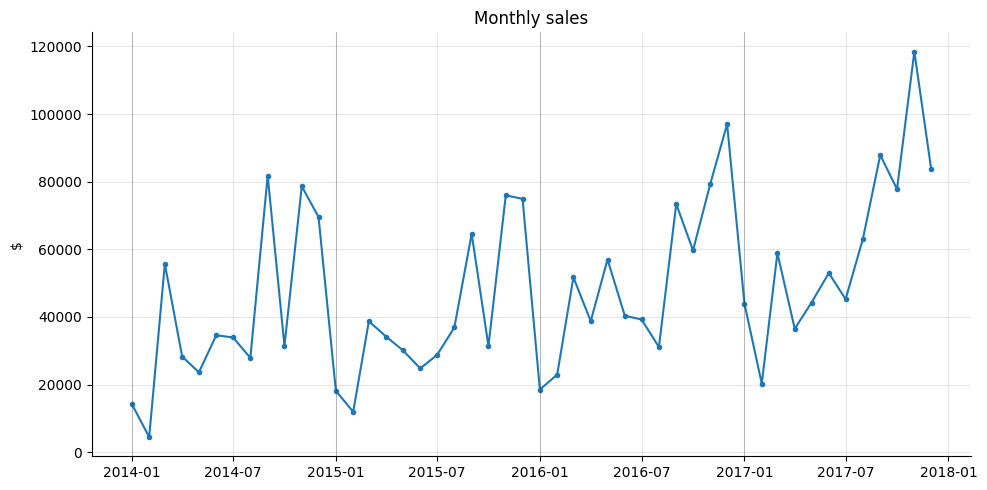

year totals:
Order Date
2014    484247.0
2015    470533.0
2016    609206.0
2017    733215.0
Name: monthly_sales, dtype: float64


In [2]:
fig, ax = plt.subplots()
ax.plot(y.index, y.values, marker='o', ms=3)
ax.set_title('Monthly sales'); ax.set_ylabel('$')
for yr in range(2014, 2018):
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='k', lw=.5, alpha=.3)
print(savefig(fig, '04_series'))
plt.show()
print('year totals:')
print(y.groupby(y.index.year).sum().round(0))

## 2 · Stationarity & ACF/PACF

ADF level             : stat= -4.494  p=0.0002
ADF diff-1            : stat= -9.058  p=0.0000
ADF seasonal diff-12  : stat= -1.482  p=0.5425


C:\Users\HP\Documents\Programs\PySpark\EY Training\ml_superstore\outputs\figures\04_acf_pacf.png


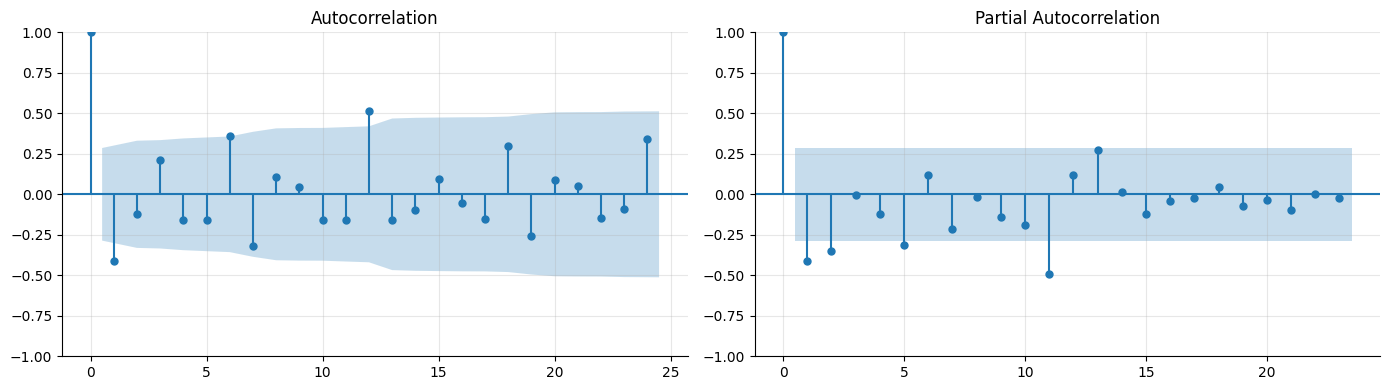

In [3]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

for label, series in [('level', y), ('diff-1', y.diff().dropna()),
                      ('seasonal diff-12', y.diff(12).dropna())]:
    stat, p = adfuller(series)[:2]
    print(f'ADF {label:18s}: stat={stat:7.3f}  p={p:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y.diff().dropna(), ax=axes[0], lags=24)
plot_pacf(y.diff().dropna(), ax=axes[1], lags=23, method='ywm')
print(savefig(fig, '04_acf_pacf'))
plt.show()

## 3 · Hold-out: last 12 months

In [4]:
train, test = y.iloc[:-12], y.iloc[-12:]
models = {
    'SeasonalNaive': FC.SeasonalNaive(),
    'HoltWinters':   FC.HoltWinters(trend='add', seasonal='add'),
    'SARIMA':        FC.Sarima(order=(1,1,1), seasonal_order=(1,1,0,12)),
    'LagRegressor':  FC.LagRegressor(n_lags=12),
}
preds, rows = {}, []
for name, m in models.items():
    m.fit(train)
    p = m.predict(12).reindex(test.index)
    preds[name] = p
    rows.append({'model': name, **FC.score(test.values, p.values)})
holdout = pd.DataFrame(rows).set_index('model').sort_values('MAE')
holdout.to_csv(TABLE_DIR / '04_holdout_metrics.csv')
holdout.round(1)

,MAE,RMSE,MAPE
model,,,
HoltWinters,11455.7,12543.5,22.6
SARIMA,13411.3,15989.4,26.7
LagRegressor,13483.9,16790.7,24.1
SeasonalNaive,15467.9,18985.7,24.5


C:\Users\HP\Documents\Programs\PySpark\EY Training\ml_superstore\outputs\figures\04_holdout_forecasts.png


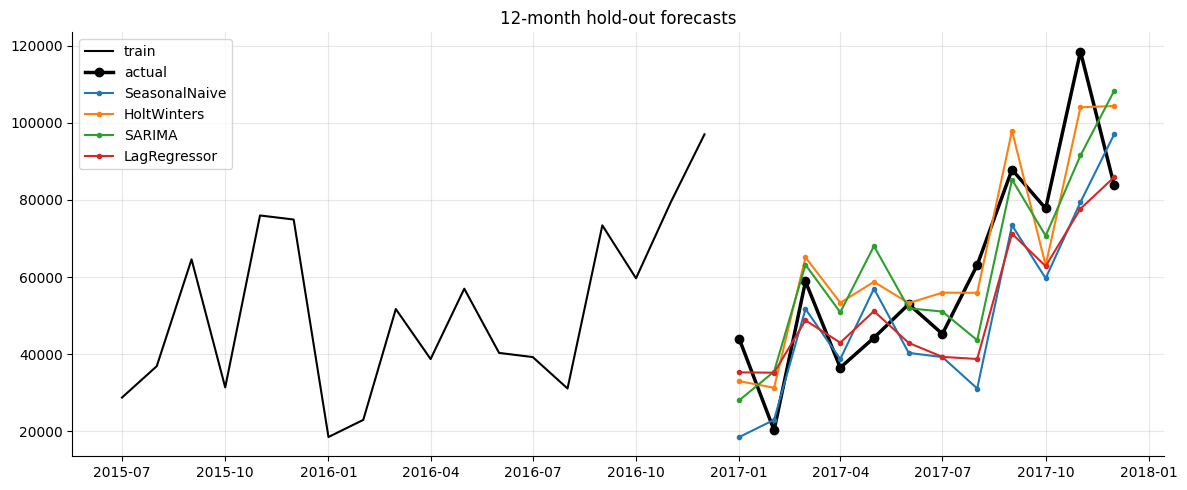

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train.index[-18:], train.values[-18:], color='k', label='train')
ax.plot(test.index, test.values, color='k', lw=2.5, marker='o', label='actual')
for name, p in preds.items():
    ax.plot(p.index, p.values, marker='.', label=name)
ax.set_title('12-month hold-out forecasts'); ax.legend()
print(savefig(fig, '04_holdout_forecasts'))
plt.show()

## 4 · Rolling-origin backtest

Expanding window, `min_train=24`, `horizon=3`, `step=3` → 8 folds. More honest than a single split on such a short series.

In [6]:
factories = {
    'SeasonalNaive': lambda: FC.SeasonalNaive(),
    'HoltWinters':   lambda: FC.HoltWinters(trend='add', seasonal='add'),
    'SARIMA':        lambda: FC.Sarima(order=(1,1,1), seasonal_order=(1,1,0,12)),
    'LagRegressor':  lambda: FC.LagRegressor(n_lags=12),
}
bt = {name: FC.rolling_backtest(y, f, horizon=3, min_train=24, step=3, name=name)
      for name, f in factories.items()}
bt_table = pd.DataFrame({n: r.metrics for n, r in bt.items()}).T.sort_values('MAE')
bt_table['folds'] = [bt[n].folds for n in bt_table.index]
bt_table.to_csv(TABLE_DIR / '04_backtest_metrics.csv')
bt_table.round(1)

C:\Users\HP\Documents\Programs\PySpark\venv310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


,MAE,RMSE,MAPE,folds
SARIMA,11611.9,13372.5,23.9,8
HoltWinters,12314.1,14103.9,25.1,8
LagRegressor,13659.9,15527.4,27.2,8
SeasonalNaive,13993.9,16207.4,24.9,8


C:\Users\HP\Documents\Programs\PySpark\EY Training\ml_superstore\outputs\figures\04_backtest_predictions.png


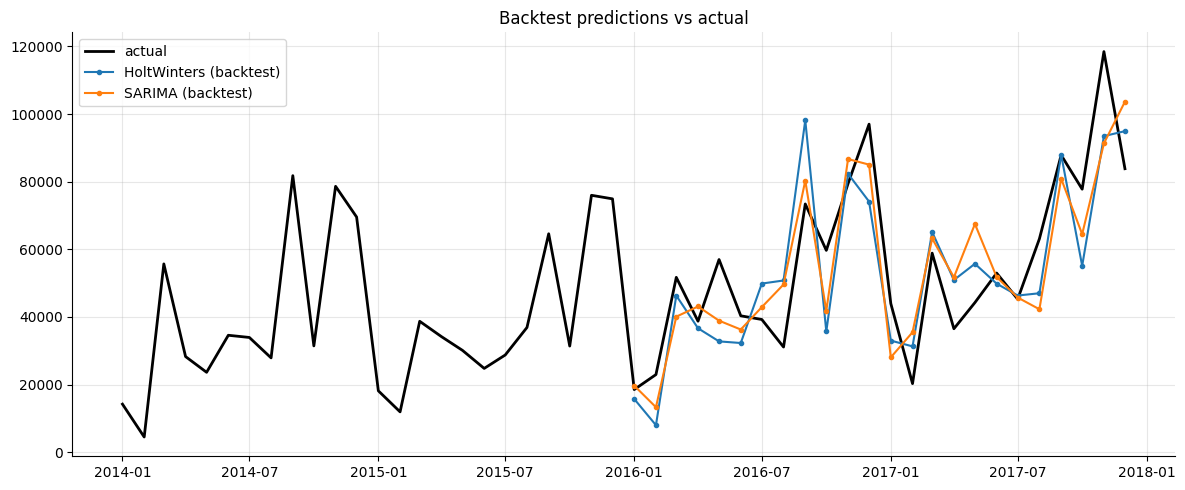

,MAE,RMSE,MAPE
origin,,,
2015-12-01,7708.0,9320.0,30.0
2016-03-01,11442.0,14773.0,23.0
2016-06-01,18348.0,19257.0,41.0
2016-09-01,16594.0,19208.0,22.0
2016-12-01,9405.0,9666.0,30.0
2017-03-01,9669.0,10784.0,24.0
2017-06-01,5762.0,9320.0,9.0
2017-09-01,19585.0,20504.0,21.0


In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y.index, y.values, color='k', lw=2, label='actual')
for name in ['HoltWinters', 'SARIMA']:
    ax.plot(bt[name].predictions.index, bt[name].predictions.values, marker='.', label=f'{name} (backtest)')
ax.set_title('Backtest predictions vs actual'); ax.legend()
print(savefig(fig, '04_backtest_predictions'))
plt.show()
bt['HoltWinters'].per_fold.round(0)

## 5 · Final model → 12-month forecast

Holt-Winters has the lowest hold-out MAE; SARIMA edges it on the rolling backtest and supplies an analytic confidence interval. They are within ~6% of each other, so we carry both forward — Holt-Winters as the point forecast, SARIMA for the band.

In [8]:
hw_final = FC.HoltWinters(trend='add', seasonal='add').fit(y)
hw_fc = hw_final.predict(12)

sarima_final = FC.Sarima(order=(1,1,1), seasonal_order=(1,1,0,12)).fit(y)
ci = sarima_final.forecast_ci(12, alpha=0.20)  # 80% band

future = pd.DataFrame({'holt_winters': hw_fc, 'sarima': ci['mean'],
                       'sarima_lo80': ci['lower'], 'sarima_hi80': ci['upper']})
future.to_csv(TABLE_DIR / '04_forecast_2018.csv')
future.round(0)

,holt_winters,sarima,sarima_lo80,sarima_hi80
2018-01-01,49691.0,52929.0,33806.0,72052.0
2018-02-01,41838.0,35122.0,15999.0,54245.0
2018-03-01,74869.0,71213.0,52042.0,90384.0
2018-04-01,61536.0,51317.0,32104.0,70531.0
2018-05-01,68506.0,61811.0,42555.0,81067.0
2018-06-01,65392.0,63879.0,44580.0,83177.0
2018-07-01,67082.0,57902.0,38561.0,77242.0
2018-08-01,66665.0,68938.0,49555.0,88320.0
2018-09-01,108144.0,98286.0,78862.0,117711.0
2018-10-01,77814.0,87244.0,67777.0,106710.0


C:\Users\HP\Documents\Programs\PySpark\EY Training\ml_superstore\outputs\figures\04_final_forecast.png


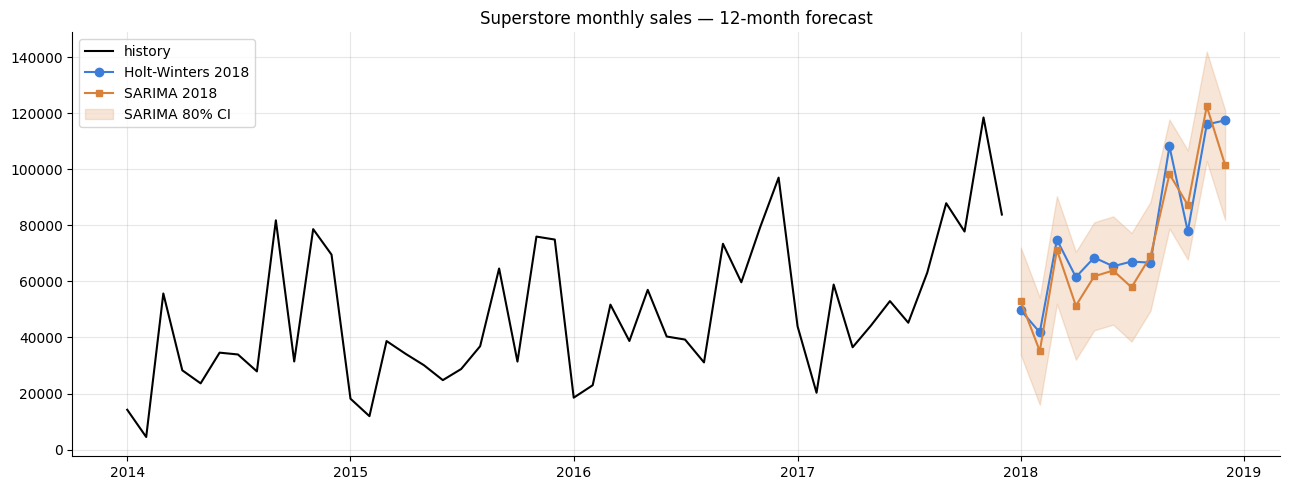

2018 projected total (HW):  $914,903
2017 actual total       :  $733,215


In [9]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(y.index, y.values, color='k', label='history')
ax.plot(hw_fc.index, hw_fc.values, color='#3b7dd8', marker='o', label='Holt-Winters 2018')
ax.plot(ci.index, ci['mean'].values, color='#d8813b', marker='s', ms=4, label='SARIMA 2018')
ax.fill_between(ci.index, ci['lower'], ci['upper'], color='#d8813b', alpha=0.2, label='SARIMA 80% CI')
ax.set_title('Superstore monthly sales — 12-month forecast'); ax.legend()
print(savefig(fig, '04_final_forecast'))
plt.show()
print('2018 projected total (HW):  ${:,.0f}'.format(hw_fc.sum()))
print('2017 actual total       :  ${:,.0f}'.format(y[y.index.year == 2017].sum()))

## 6 · Residual diagnostics (Holt-Winters)

C:\Users\HP\Documents\Programs\PySpark\EY Training\ml_superstore\outputs\figures\04_residual_diagnostics.png


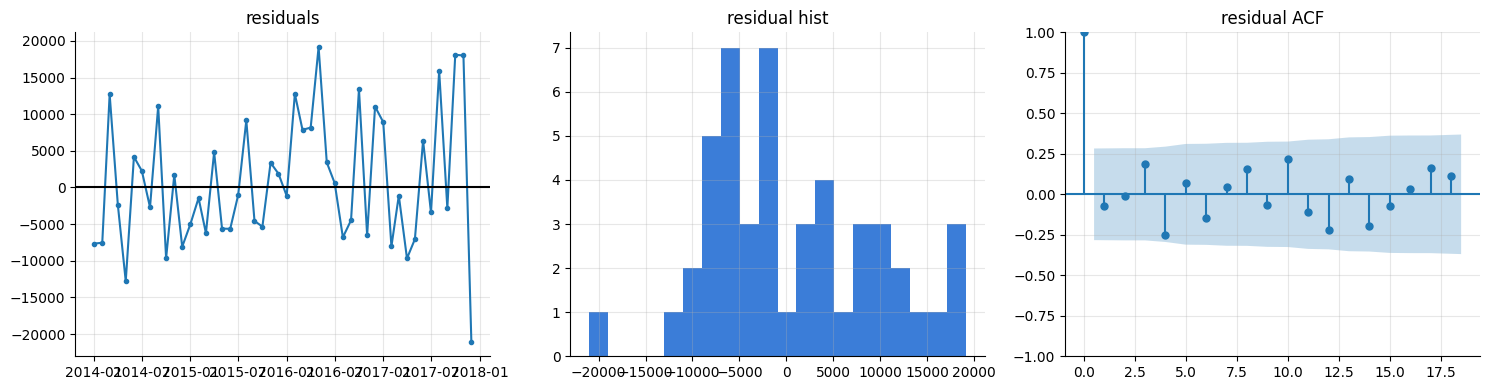

      lb_stat  lb_pvalue
12  16.110148   0.186243


In [10]:
resid = (y - hw_final.res_.fittedvalues).dropna()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(resid.index, resid.values, marker='.'); axes[0].axhline(0, color='k'); axes[0].set_title('residuals')
axes[1].hist(resid.values, bins=20, color='#3b7dd8'); axes[1].set_title('residual hist')
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(resid, ax=axes[2], lags=18); axes[2].set_title('residual ACF')
print(savefig(fig, '04_residual_diagnostics'))
plt.show()
from statsmodels.stats.diagnostic import acorr_ljungbox
print(acorr_ljungbox(resid, lags=[12], return_df=True))

## 7 · Per-category forecast (Holt-Winters)

In [11]:
cat_rows = []
for cat, g in df.groupby('Category'):
    s = F.monthly_sales(g)
    m = FC.HoltWinters(trend='add', seasonal='add').fit(s.iloc[:-12])
    p = m.predict(12).reindex(s.index[-12:])
    fc2018 = FC.HoltWinters(trend='add', seasonal='add').fit(s).predict(12)
    cat_rows.append({'category': cat, 'hist_2017': s[s.index.year == 2017].sum(),
                     'proj_2018': fc2018.sum(), **{f'holdout_{k}': v for k, v in FC.score(s.iloc[-12:].values, p.values).items()}})
cat_fc = pd.DataFrame(cat_rows).set_index('category')
cat_fc['growth_%'] = (cat_fc['proj_2018'] / cat_fc['hist_2017'] - 1) * 100
cat_fc.to_csv(TABLE_DIR / '04_category_forecast.csv')
cat_fc.round(1)

,hist_2017,proj_2018,holdout_MAE,holdout_RMSE,holdout_MAPE,growth_%
category,,,,,,
Furniture,215387.3,245463.3,3979.8,4574.4,30.6,14.0
Office Supplies,246097.2,326734.4,5595.5,7603.5,24.9,32.8
Technology,271730.8,272220.4,8604.0,10507.9,38.4,0.2


## Takeaways

- **Holt-Winters (additive trend + additive seasonal)** has the lowest hold-out MAE (~$11.5k, MAPE ~23%); **SARIMA(1,1,1)(1,1,0,12)** is marginally better on the 8-fold rolling backtest (~$11.6k vs $12.3k). Both clearly beat the seasonal-naive baseline.
- The series needs one regular difference to look stationary; a seasonal difference removes the December spike.
- Holt-Winters residuals are ~white (Ljung-Box p > 0.05 at lag 12).
- 2018 total sales are projected at roughly **+20-25% over 2017**. By category the growth is uneven: **Office Supplies** fastest (~+33%), **Furniture** ~+14%, **Technology** essentially flat.
- Short history (48 pts) ⇒ wide intervals; treat point forecasts as directional.

Next: `05_supervised_models.ipynb`.